In [2]:
#Aim: to keep the notebook as clean as possible. 
# make it for any variable
# change: Multiple Obs variables

In [3]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

%matplotlib inline

In [4]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_obs_data = "/Users/ud4/Documents/FACEMDS/L2FR_Calc"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

In [5]:

fnames={}

#case_ids = [
#            "FACE_1PFT_r250210_Best_Cal", # SC: Successional and Calibrated
#            "FACE_1PFT_r250314_defParams", # SD: Successional and Default Params (except Vmax)
#            "FACE_1PFT_r250314_NoLog_CalParams", #EC: Equilibrium and Calibrated
#            "FACE_1PFT_r2503121_ED_b4OLMTparms", #ED: Equilibrium and Default | see notes for details
#           ]

case_abr = { # case abbreviations
    "SC" : "FACE_1PFT_r250210_Best_Cal",
    "SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
    "EC" : "FACE_1PFT_r250314_NoLog_CalParams",
    "ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",
#SD: FACE_1PFT_r2503121_SD_b4OLMTparms | it will replace the above

}

site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}


sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly",
            "RD",
            "ECA",
            ]

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            # COnly
            fnames[f"{c_abr}_{s_abr}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
            # RD
            #fn = ['RD','ECA']
            for fn in ['RD','ECA']:
                fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}.nc"

In [6]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    #print (key, ":" , fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key])
    

In [7]:
# Mean annual files
filename_ORNL_ax  = f"{path_obs_data}/data/ORNL_ax.csv"
filename_DUKE_ax  = f"{path_obs_data}/data/DUKE_ax.csv"
filename_ORNL_ase  = f"{path_obs_data}/data/ORNL_ase.csv"
filename_DUKE_ase  = f"{path_obs_data}/data/DUKE_ase.csv"


df_ORNL_ax = pd.read_csv(filename_ORNL_ax)
df_DUKE_ax = pd.read_csv(filename_DUKE_ax)
df_ORNL_ase = pd.read_csv(filename_ORNL_ase)
df_DUKE_ase = pd.read_csv(filename_DUKE_ase)

In [8]:
df_ORNL_ase.columns

Index(['year', 'co2', 'fc_grow_wood', 'fc_grow_croot', 'fc_grow_leaf',
       'fc_grow_froot', 'fc_npp', 'c_wood', 'c_croot', 'c_leaf', 'c_froot',
       'fc_leaf_litter', 'fc_froot_to_litter', 'fc_wood_to_litter',
       'fn_leaf_to_litter', 'fn_wood_to_litter', 'n_leaf_peak', 'n_wood',
       'n_croot', 'n_froot', 'fn_grow_leaf', 'fn_grow_wood', 'fn_grow_froot',
       'fn_plantuptake', 'fn_grossmin', 'fn_netmin ', 'ptrait_lai',
       'ptrait_lai_peak', 'fw_transp '],
      dtype='object')

## Inputs

In [9]:
case_abr

{'SC': 'FACE_1PFT_r250210_Best_Cal',
 'SD': 'FACE_1PFT_r2503121_SD_b4OLMTparms',
 'EC': 'FACE_1PFT_r250314_NoLog_CalParams',
 'ED': 'FACE_1PFT_r2503121_ED_b4OLMTparms'}

In [10]:
# Inputs
# ======

case_plot = "SC" # 'SC', 'SD','EC', 'ED'
#var_obs= "NPP"

# Allocation Carbon
fig_name = "allocationC"
var_obs_names = {}
var_obs_names ["ORNL"] = ['fc_grow_leaf', 'fc_grow_wood', 'fc_grow_froot','fc_grow_croot']
var_obs_names ["DUKE"] = ['fc_grow_leaf', 'fc_grow_wood', 'fc_grow_froot','fc_grow_repr']

#. N pools
#fig_name = "poolN"
#var_obs_names = {}
#var_obs_names ["ORNL"] = ['n_leaf', 'n_wood', 'n_froot']
#var_obs_names ["DUKE"] = ['n_leaf', 'n_wood', 'n_froot']

# make dictionary of plots
# ------------------------
data_plots = {}
data_plots_obs = {}
data_plots[case_plot] = {}
if fig_name == "allocationC":
    var_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        #"NPP_alloc",
        "FATES_STORE_ALLOC",
        "FATES_LEAF_ALLOC",
        "FATES_STEM_ALLOC",
        "FATES_FROOT_ALLOC",
        "FATES_CROOT_ALLOC",
        "FATES_SEED_ALLOC",


       )
if fig_name == "poolN":
    var_names = (
    "FATES_STOREN",
    "FATES_LEAFN",
    "FATES_SAPWOODN",
    "FATES_FROOTN",
    "FATES_REPRON",
    #"FATES_VEGN",
    )
    

# plot obs? 
obs_plot = 1 # 0,1

In [11]:
# Reading Obs and selection based on Input

In [12]:
# Peak LAI in column name is 'ptrait_lai_peak'
#obs_col_name = 'c_veg'

if fig_name == "allocationC":
    df_ORNL_select_ax = df_ORNL_ax[['year','co2','fc_grow_wood', 'fc_grow_croot', 'fc_grow_leaf','fc_grow_froot']].copy()
    df_DUKE_select_ax = df_DUKE_ax[['year','co2','fc_grow_wood', 'fc_grow_repr', 'fc_grow_leaf','fc_grow_froot']].copy()
    df_ORNL_select_ase = df_ORNL_ase[['year','co2','fc_grow_wood', 'fc_grow_croot', 'fc_grow_leaf','fc_grow_froot']].copy()
    df_DUKE_select_ase = df_DUKE_ase[['year','co2','fc_grow_wood', 'fc_grow_repr', 'fc_grow_leaf','fc_grow_froot']].copy()
    # because DUKE se has strs
    cols_to_convert = ['fc_grow_wood', 'fc_grow_repr', 'fc_grow_leaf','fc_grow_froot']
    var_names_ornl = ['fc_grow_wood', 'fc_grow_croot', 'fc_grow_leaf','fc_grow_froot']
    var_names_duke = ['fc_grow_wood', 'fc_grow_repr', 'fc_grow_leaf','fc_grow_froot']
    obs_var_units = "g m-2 yr-1"

if fig_name == "poolN":
    df_ORNL_select_ax = df_ORNL_ax[['year','co2','n_leaf_peak', 'n_wood', 'n_froot']].copy()
    df_DUKE_select_ax = df_DUKE_ax[['year','co2','n_leaf', 'n_wood', 'n_froot']].copy()
    df_ORNL_select_ase = df_ORNL_ase[['year','co2','n_leaf_peak', 'n_wood', 'n_froot']].copy()
    df_DUKE_select_ase = df_DUKE_ase[['year','co2','n_leaf', 'n_wood', 'n_froot']].copy()    
    
    # ORNL has has n_leaf_peak instead of n_leaf, so rename it to n_leaf
    df_ORNL_select_ax = df_ORNL_select_ax.rename(columns={'n_leaf_peak': 'n_leaf'})
    df_ORNL_select_ase = df_ORNL_select_ase.rename(columns={'n_leaf_peak': 'n_leaf'})
    # because DUKE se has strs
    cols_to_convert = ['n_leaf', 'n_wood', 'n_froot']
    var_names_ornl = ['n_leaf', 'n_wood', 'n_froot']
    var_names_duke = ['n_leaf', 'n_wood', 'n_froot']
    obs_var_units = "g m-2"
    
if fig_name == "c_veg":
    df_ORNL_select_ax ["c_veg"] = df_ORNL_select_ax.filter(like="c_").sum(axis=1)
    df_DUKE_select_ax ["c_veg"] = df_DUKE_select_ax.filter(like="c_").sum(axis=1)
    # sum of standard error
    df_ORNL_select_ase ["c_veg"] = np.sqrt(df_ORNL_select_ase.filter(like="c_").pow(2).sum(axis=1))
    df_DUKE_select_ase ["c_veg"] = np.sqrt(df_DUKE_select_ase.filter(like="c_").pow(2).sum(axis=1))

df_ORNL_select_ax['site'] = "ORNL"
df_DUKE_select_ax['site'] = "DUKE"
df_ORNL_select_ase ['site'] = "ORNL"
df_DUKE_select_ase ['site'] = "DUKE"


# for DUKE
df_DUKE_select_ax[cols_to_convert] = df_DUKE_select_ax[cols_to_convert].apply(pd.to_numeric, errors='coerce')
df_DUKE_select_ase[cols_to_convert] = df_DUKE_select_ase[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#var_name_obs = "c_veg"


In [13]:
#var_name_obs = "c_veg"
#obs_var_units = "g m-2"
df_obs_ax = pd.concat([df_ORNL_select_ax, df_DUKE_select_ax], ignore_index=True)
#df_obs_ax.rename(columns={"ptrait_cveg_peak": "Peak_cveg"}, inplace=True)
df_obs_ax.rename(columns={"year": "YEAR"}, inplace=True)
# Replace negative values with NaN
df_obs_ax[df_obs_ax.select_dtypes(include=[np.number]) < 0] = np.nan

df_obs_ase = pd.concat([df_ORNL_select_ase, df_DUKE_select_ase], ignore_index=True)
#df_obs_ase.rename(columns={"ptrait_cveg_peak": "Peak_cveg"}, inplace=True)
df_obs_ase.rename(columns={"year": "YEAR"}, inplace=True)


In [14]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file

In [15]:

markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 
colors_list = ["blue", "orange", "green", "purple","red", "brown"]#, "blue", "yellow"] 

#def tmp_legend_name (key):
#    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [16]:
# dataframe of selected colms 
# relevant columns
#rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
#df_obs_ax = my_data[rel_cols]
#df_obs_ase = my_data_se[rel_cols]

#NPP_units = "gC m-2 y-1"
#NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_27810/2569702567.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_27810/2569702567.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_27810/2569702567.py:39: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]


In [21]:
var_names

('FATES_STORE_ALLOC',
 'FATES_LEAF_ALLOC',
 'FATES_STEM_ALLOC',
 'FATES_FROOT_ALLOC',
 'FATES_CROOT_ALLOC',
 'FATES_SEED_ALLOC')

# Plot a and e CO2

0 FATES_STORE_ALLOC None
allocation to storage tissues in kg carbon per m2 per second
allocation to storage tissues in kg carbon per m2 per second
1 FATES_LEAF_ALLOC fc_grow_leaf
allocation to leaves in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
2 FATES_STEM_ALLOC fc_grow_wood
allocation to stem in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
3 FATES_FROOT_ALLOC fc_grow_froot
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
4 FATES_CROOT_ALLOC fc_grow_croot
allocation to coarse roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
5 FATES_SEED_ALLOC fc_grow_repr
allocation to seeds in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
fig end COnly ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/allocationC_sce_SC_ORNL_COnly.pdf


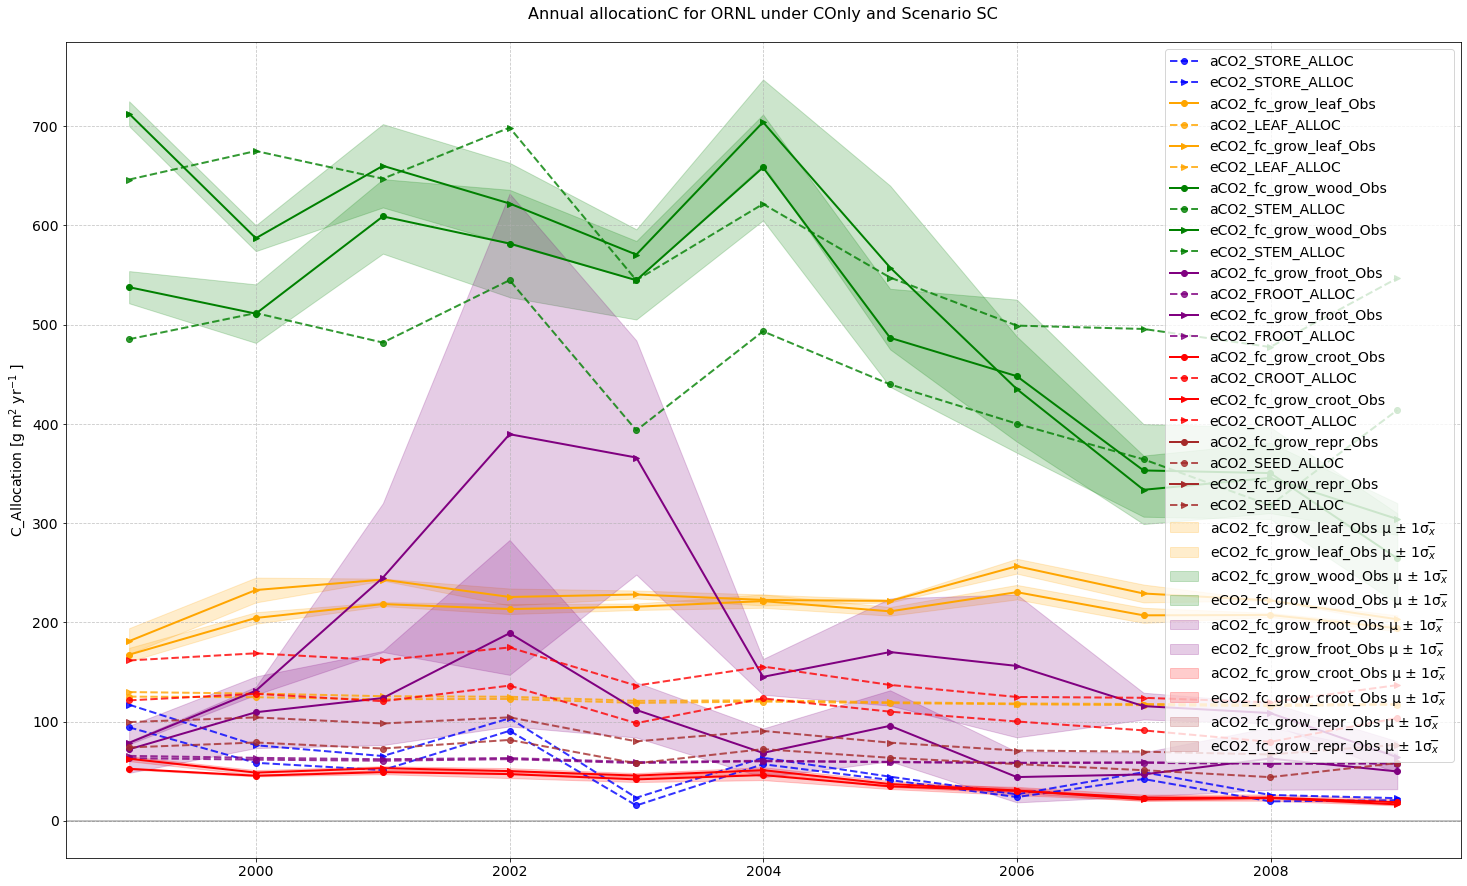

0 FATES_STORE_ALLOC None
allocation to storage tissues in kg carbon per m2 per second
allocation to storage tissues in kg carbon per m2 per second
1 FATES_LEAF_ALLOC fc_grow_leaf
allocation to leaves in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
2 FATES_STEM_ALLOC fc_grow_wood
allocation to stem in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
3 FATES_FROOT_ALLOC fc_grow_froot
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
4 FATES_CROOT_ALLOC fc_grow_croot
allocation to coarse roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
5 FATES_SEED_ALLOC fc_grow_repr
allocation to seeds in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
fig end RD ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/allocationC_sce_SC_ORNL_RD.pdf


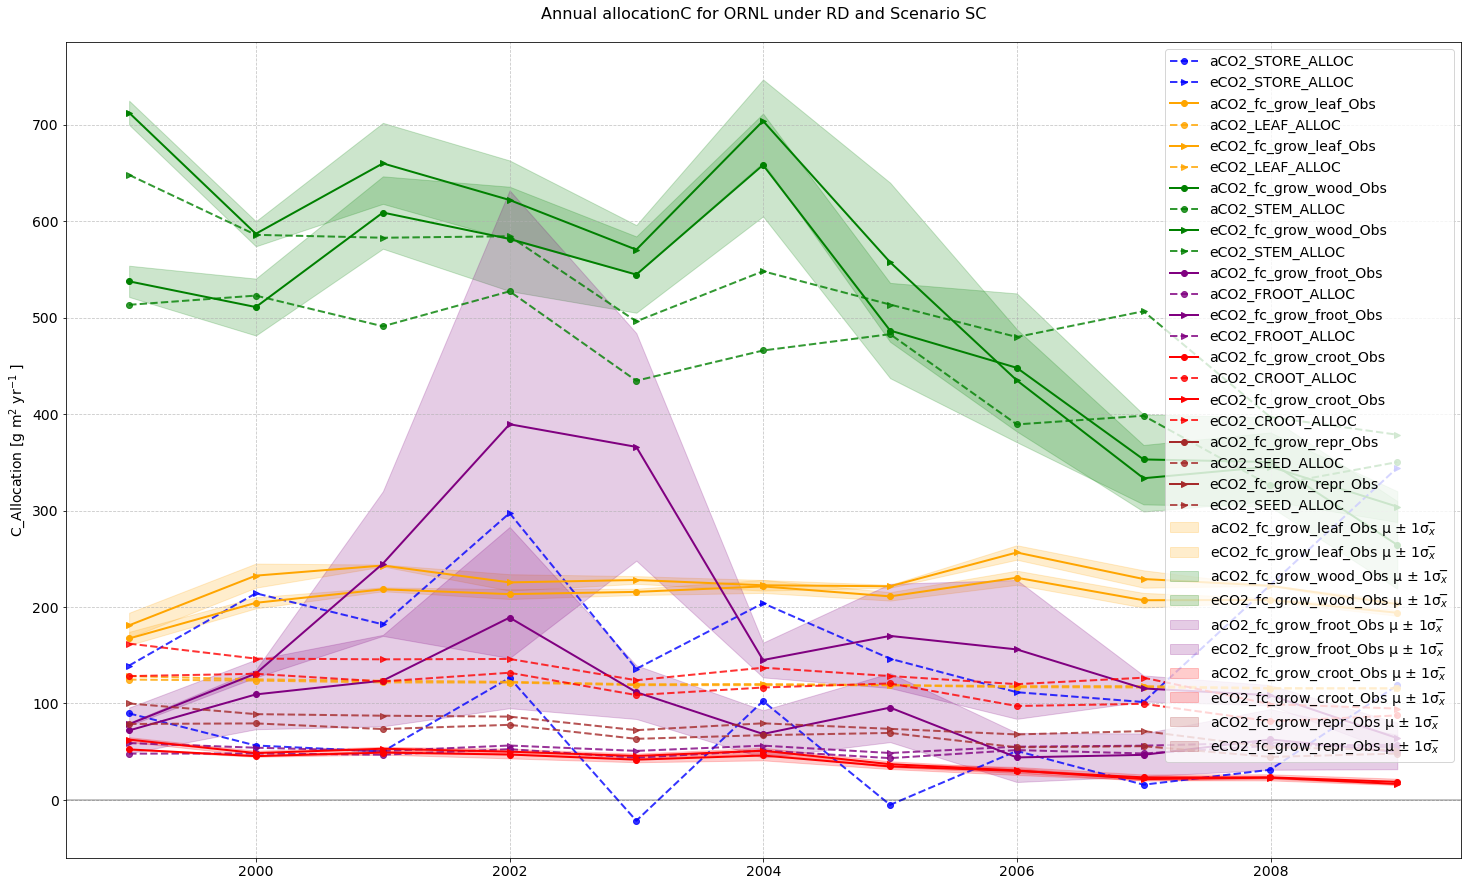

0 FATES_STORE_ALLOC None
allocation to storage tissues in kg carbon per m2 per second
allocation to storage tissues in kg carbon per m2 per second
1 FATES_LEAF_ALLOC fc_grow_leaf
allocation to leaves in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
2 FATES_STEM_ALLOC fc_grow_wood
allocation to stem in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
3 FATES_FROOT_ALLOC fc_grow_froot
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
4 FATES_CROOT_ALLOC fc_grow_croot
allocation to coarse roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
5 FATES_SEED_ALLOC fc_grow_repr
allocation to seeds in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
fig end ECA ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/allocationC_sce_SC_ORNL_ECA.pdf


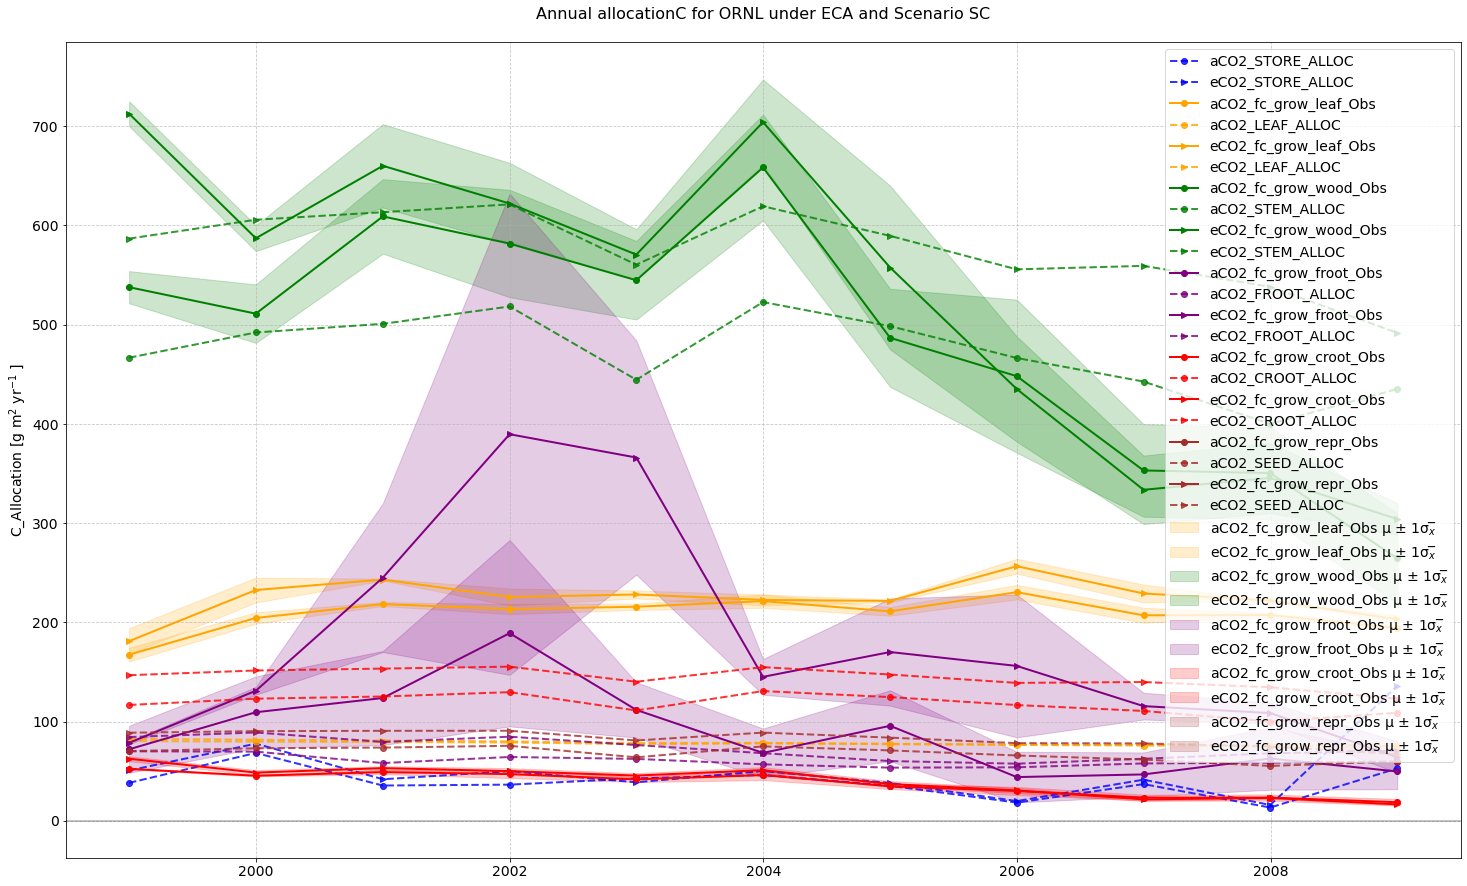

In [23]:

select_site = "US-ORN"
site = "ORNL"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index

for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(25,15))
    #print ("fig start",sim_case)
    var_obs= None
    for cii,var in enumerate (var_names):
        # C allocation 
        if var == "FATES_FROOT_ALLOC": 
            var_obs = "fc_grow_froot"
        if var == "FATES_LEAF_ALLOC":
            var_obs = "fc_grow_leaf"
        if var == "FATES_SEED_ALLOC":
            var_obs = "fc_grow_repr"
        if var == "FATES_STEM_ALLOC":
            var_obs = "fc_grow_wood"
        if var == "FATES_CROOT_ALLOC":
            var_obs = "fc_grow_croot"
        # N Pool    
        if var == "FATES_LEAFN": 
            var_obs = "n_leaf"
        if var == "FATES_SAPWOODN":
            var_obs = "n_wood"
        if var == "FATES_FROOTN":
            var_obs = "n_froot"
        print (cii,var,var_obs)
        
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
    
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = colors_list[cii]#"b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = colors_list[cii]#"green"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = colors_list[cii]#"r"
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = colors_list[cii]#"purple"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (
                    var not in ["FATES_STORE_ALLOC",
                                "FATES_REPRON",
                                "FATES_STOREN",
                                "FATES_VEGN",]
                        ):# and (ran_twice<2):
                    #print (cii,var,var_obs,key)
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_nup = Mean_DF[f'{var_obs}']
                    se_nup = Standard_error_DF[f'{var_obs}']
                    # Plot NUP with shaded error bars
                    plt.plot(time, mean_nup, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, marker= marker_line, lw=2)
                    lower_bound = (mean_nup - se_nup).astype(float)
                    upper_bound = (mean_nup + se_nup).astype(float)
                    plt.fill_between(time, lower_bound, upper_bound, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    #print (cii+100,var,var_obs,key)
                    #plt.fill_between(time, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color=color_obs, alpha=0.15)
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_nup"] = np.array(mean_nup)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_lower"] = np.array(lower_bound)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_upper"] = np.array(upper_bound)
                    
                    ran_twice +=1
                    
                if var == "FATES_VEGC":
                    tmp_var = ds[key]['FATES_VEGC'] *1000
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ var.split('_')[-1], 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    
                if var == "FATES_VEGC_ABOVEGROUND":
                    tmp_var = ds[key]['FATES_VEGC_ABOVEGROUND'] *1000
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "_".join(var.split('_')[1:]), 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]

                if "ALLOC" in var:
                    # for carbon allocation flux
                    tmp_var = ds[key][var] *1000*365*24*60*60 # kg m-2 s-1 to g m-2 yr-1
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "_".join(var.split('_')[1:]), 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    print (ds[key][var].long_name )
                if ("N" == var[-1]) and ("COnly" not in key):
                    # for N pool in fates
                    tmp_var = ds[key][var] *1000 # kg m-2 to g m-2 
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "_".join(var.split('_')[1:]), 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                if fig_name == "allocationC":
                    plt.ylabel(r"C_Allocation [g m$^{2}$ yr$^{-1}$ ]", fontsize=14)
                if fig_name == "poolN":
                    plt.ylabel(r"N_Pool [g m$^{2}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                #plt.ylim(1,11)
                plt.title(f"Annual {fig_name} for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #plt.yscale("log")
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{fig_name}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/{fig_name}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/{fig_name}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

In [168]:
dict_obs_ax[site][co2_case]

,YEAR,co2,fc_grow_wood,fc_grow_croot,fc_grow_leaf,fc_grow_froot,site,fc_grow_repr
11,1998,ELE,712.5,62.5,181.0,78.5,ORNL,NaN
12,1999,ELE,587.0,48.5,232.5,131.0,ORNL,NaN
13,2000,ELE,660.0,53.0,243.0,245.0,ORNL,NaN
14,2001,ELE,622.0,50.0,225.5,389.5,ORNL,NaN
15,2002,ELE,570.5,45.5,228.0,366.0,ORNL,NaN
16,2003,ELE,704.0,51.0,222.5,145.0,ORNL,NaN
17,2004,ELE,557.5,37.0,221.5,170.0,ORNL,NaN
18,2005,ELE,435.0,30.5,256.5,156.0,ORNL,NaN
19,2006,ELE,333.5,21.5,229.0,115.5,ORNL,NaN
20,2007,ELE,345.5,23.0,222.0,108.5,ORNL,NaN


fig start COnly
allocation to storage tissues in kg carbon per m2 per second
allocation to storage tissues in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
fig end COnly DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/allocationC_sce_SC_DUKE_COnly.pdf


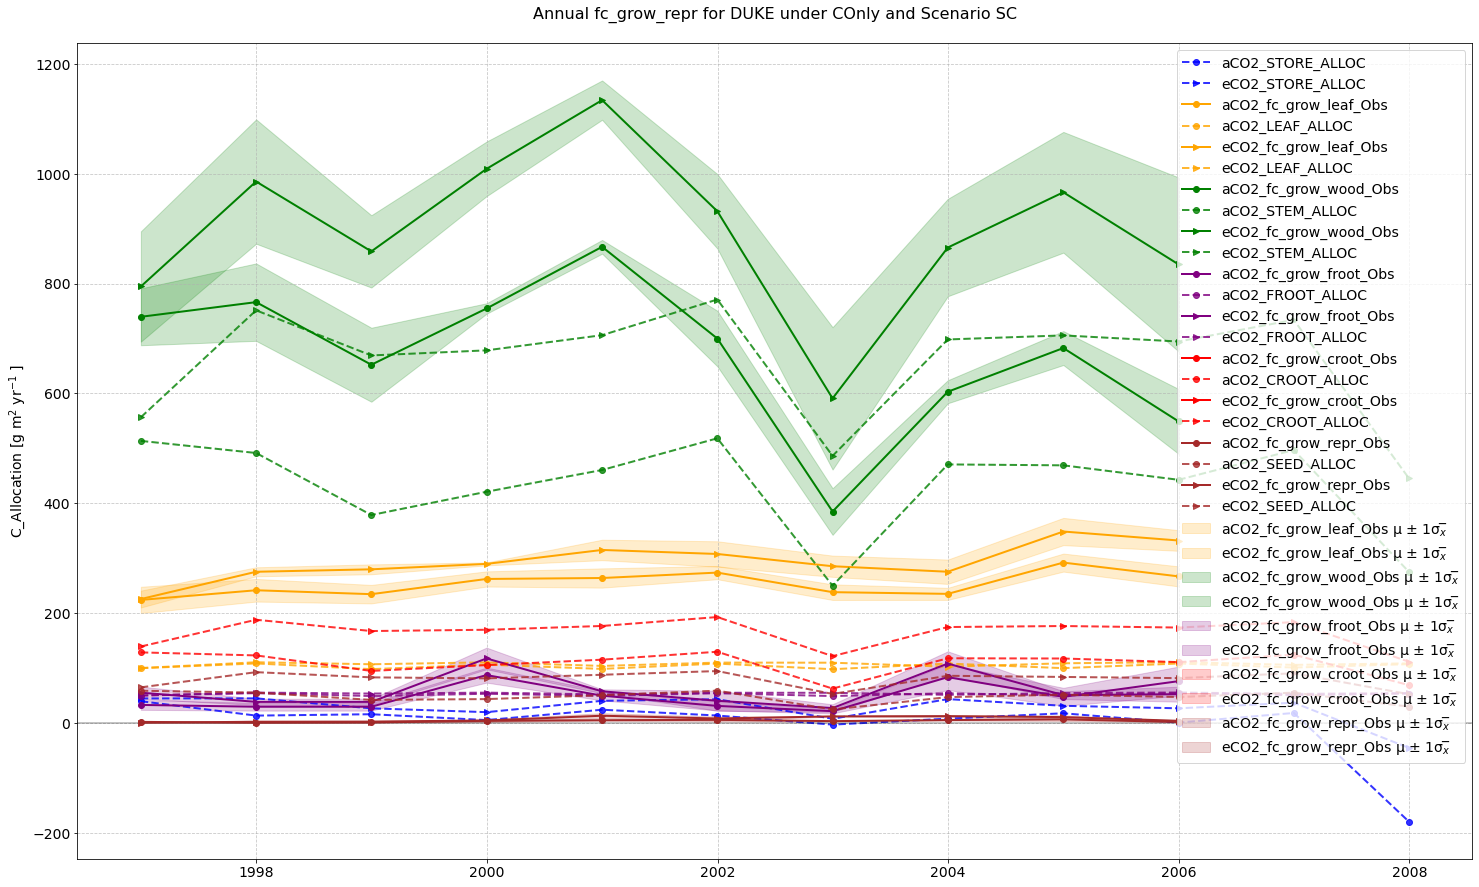

fig start RD
allocation to storage tissues in kg carbon per m2 per second
allocation to storage tissues in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
fig end RD DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/allocationC_sce_SC_DUKE_RD.pdf


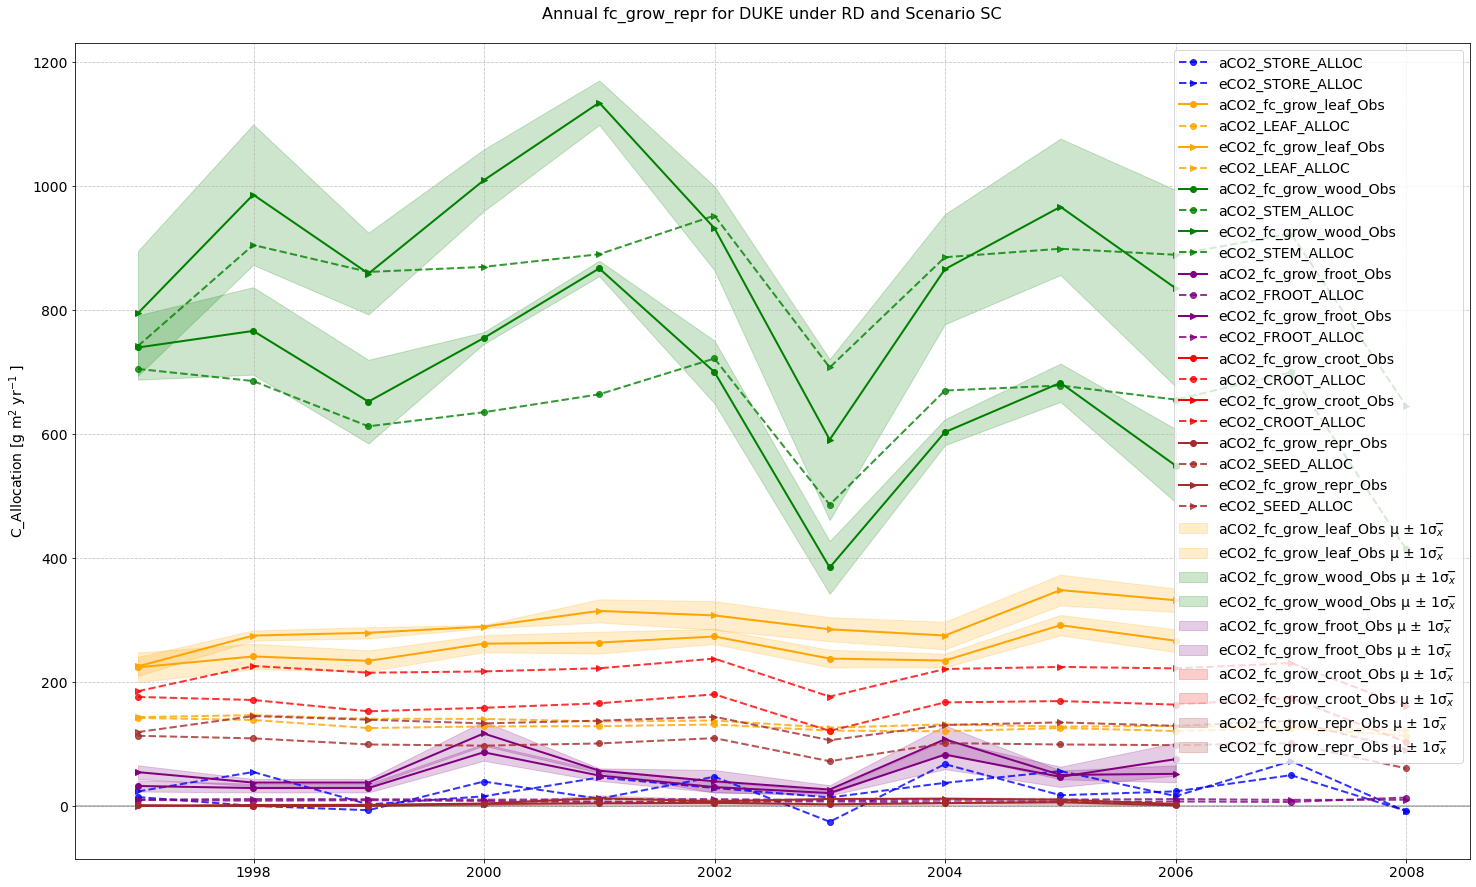

fig start ECA
allocation to storage tissues in kg carbon per m2 per second
allocation to storage tissues in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
allocation to leaves in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
allocation to stem in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
allocation to coarse roots in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
allocation to seeds in kg carbon per m2 per second
fig end ECA DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/allocationC_sce_SC_DUKE_ECA.pdf


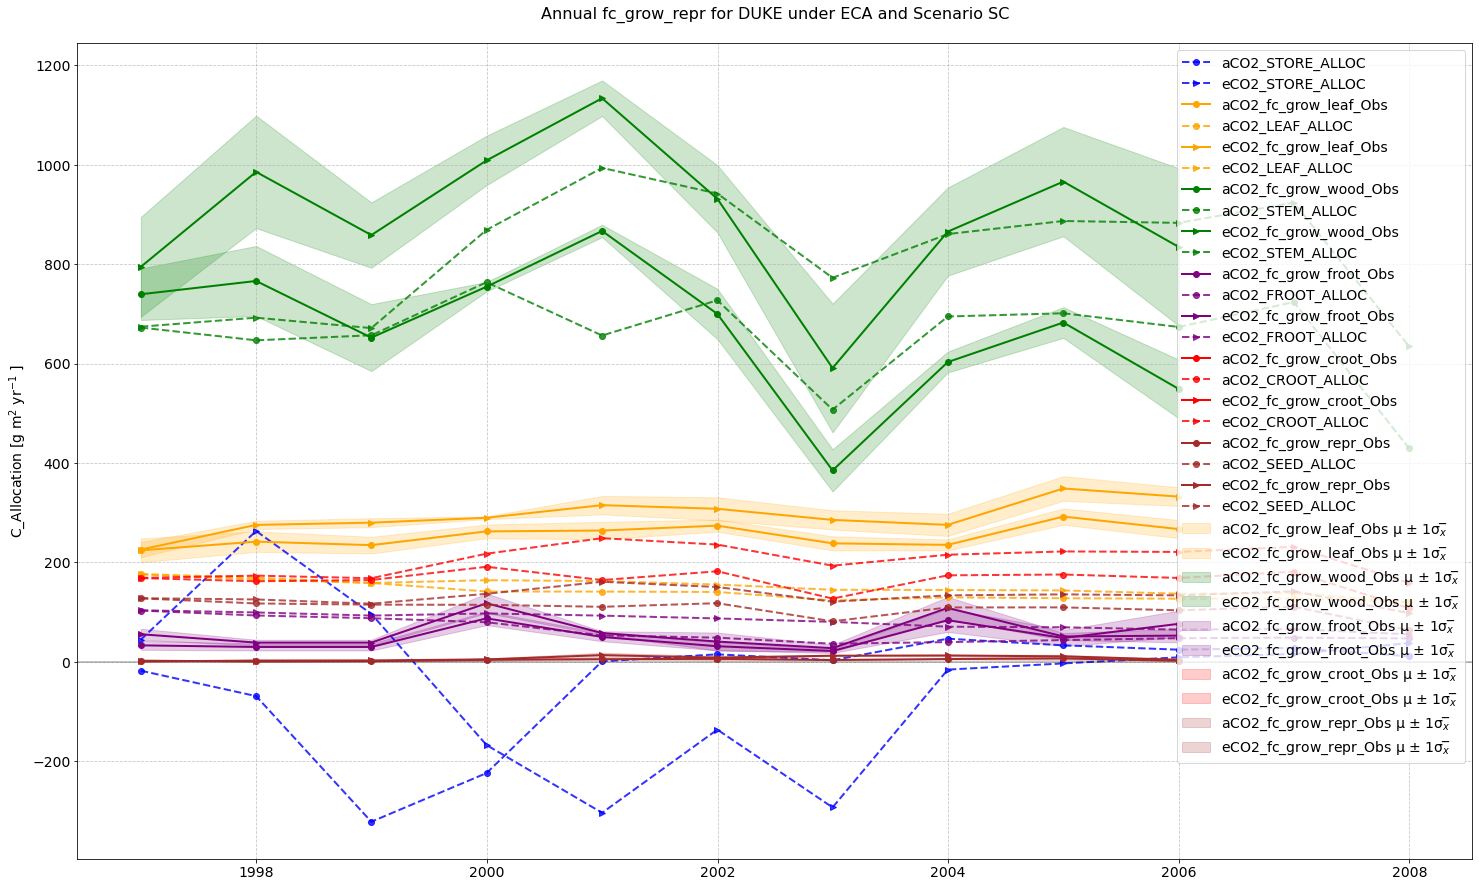

In [24]:

select_site = "US-DUK"
site = "DUKE"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
cii = -1
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(25,15))
    print ("fig start",sim_case)
    for cii,var in enumerate (var_names):
        # C allocation 
        if var == "FATES_FROOT_ALLOC": 
            var_obs = "fc_grow_froot"
        if var == "FATES_LEAF_ALLOC":
            var_obs = "fc_grow_leaf"
        if var == "FATES_SEED_ALLOC":
            var_obs = "fc_grow_repr"
        if var == "FATES_STEM_ALLOC":
            var_obs = "fc_grow_wood"
        if var == "FATES_CROOT_ALLOC":
            var_obs = "fc_grow_croot"
        # N Pool    
        if var == "FATES_LEAFN": 
            var_obs = "n_leaf"
        if var == "FATES_SAPWOODN":
            var_obs = "n_wood"
        if var == "FATES_FROOTN":
            var_obs = "n_froot"
        #print (cii,var,var_obs)
        
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
    
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = colors_list[cii]#"b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = colors_list[cii]#"green"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = colors_list[cii]#"r"
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = colors_list[cii]#"purple"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (
                    var not in ["FATES_STORE_ALLOC",
                                "FATES_REPRON",
                                "FATES_STOREN",
                                "FATES_VEGN",]
                        ):# and (ran_twice<2):
                    #print (cii,var,var_obs,key)
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_nup = Mean_DF[f'{var_obs}']
                    se_nup = Standard_error_DF[f'{var_obs}']
                    # Plot NUP with shaded error bars
                    plt.plot(time, mean_nup, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, marker= marker_line, lw=2)
                    lower_bound = (mean_nup - se_nup).astype(float)
                    upper_bound = (mean_nup + se_nup).astype(float)
                    plt.fill_between(time, lower_bound, upper_bound, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    #print (cii+100,var,var_obs,key)
                    #plt.fill_between(time, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color=color_obs, alpha=0.15)
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_nup"] = np.array(mean_nup)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_lower"] = np.array(lower_bound)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_upper"] = np.array(upper_bound)
                    ran_twice +=1
                    
                if var == "FATES_VEGC":
                    tmp_var = ds[key]['FATES_VEGC'] *1000
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ var.split('_')[-1], 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    
                if "ALLOC" in var:
                    # for carbon allocation flux
                    tmp_var = ds[key][var] *1000*365*24*60*60 # kg m-2 s-1 to g m-2 yr-1
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "_".join(var.split('_')[1:]), 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    print (ds[key][var].long_name )
                if ("N" == var[-1]) and ("COnly" not in key):
                    # for N pool in fates
                    tmp_var = ds[key][var] *1000 # kg m-2 to g m-2 
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "_".join(var.split('_')[1:]), 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                if fig_name == "allocationC":
                    plt.ylabel(r"C_Allocation [g m$^{2}$ yr$^{-1}$ ]", fontsize=14)
                if fig_name == "poolN":
                    plt.ylabel(r"N_Pool [g m$^{2}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                #plt.ylim(1,11)
                plt.title(f"Annual {var_obs} for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{fig_name}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/{fig_name}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/{fig_name}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

In [170]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1998-01-01", "2008-12-31", freq="A"
                )  # Monthly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0, 500)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a sit

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    """
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",
        format="pdf",
        bbox_inches="tight",)
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",
        format="png",
        dpi=200,
        bbox_inches="tight",)
    """
    

In [ ]:
break

In [ ]:
# NPP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                )  # Yearly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label= tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0, 600)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a site

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    